<a href="https://colab.research.google.com/github/ryanchoigit/hyperbolicgat/blob/main/Step5a_NASDAQ_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 5a: NASDAQ Data Collection

Collect price data for a broad NASDAQ universe, matching the paper's approach:
- Download all NASDAQ-listed stocks
- Filter for ≥98% data availability (paper's threshold)
- Target ~1,000 stocks to match the paper's 1,026
- Compute 5 features: return ratio, MA@5, MA@10, MA@20, MA@30
- Period: 2019–2024

---

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q yfinance

import os, json, time, warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

warnings.filterwarnings('ignore')

PROJECT_DIR = '/content/drive/MyDrive/hyperstockgat_v2'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Project dir: {PROJECT_DIR}')

Project dir: /content/drive/MyDrive/hyperstockgat_v2


## 1. Get NASDAQ Ticker List

We fetch the full list of NASDAQ-listed stocks, then filter down.
The paper used 1,026 stocks — we'll aim for a similar number by
applying their 98% data availability filter.

In [ ]:
# ============================================================
# ROBUST NASDAQ DATA DOWNLOAD
# ============================================================
# Handles: rate limiting, MultiIndex columns, empty data,
# delisted stocks, and all yfinance quirks.
#
# Estimated time: 2-3 hours for ~4000 tickers
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import time
import os
import json
import warnings
import logging
from datetime import datetime

# Suppress yfinance noise
logging.getLogger('yfinance').setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore')

# ---- CONFIG ----
START_DATE = '2019-01-01'
END_DATE = '2024-12-31'
SAVE_DIR = '/content/drive/MyDrive/hyperstockgat_v2/data'
os.makedirs(SAVE_DIR, exist_ok=True)
CHECKPOINT_FILE = os.path.join(SAVE_DIR, '_download_checkpoint.json')

# ---- GET TICKER LIST ----
url = 'https://raw.githubusercontent.com/rreichel3/US-Stock-Symbols/main/nasdaq/nasdaq_tickers.txt'
try:
    nasdaq_raw = pd.read_csv(url, header=None, names=['ticker'])
except:
    nasdaq_raw = pd.DataFrame({'ticker': []})

all_tickers = [t for t in nasdaq_raw['ticker'].tolist()
               if isinstance(t, str) and t.isalpha() and 1 <= len(t) <= 5]
# Remove ETFs
etf_exclude = {'QQQ', 'TQQQ', 'SQQQ', 'SPY', 'IWM', 'VTI', 'VOO'}
all_tickers = sorted(set(t for t in all_tickers if t not in etf_exclude))
print(f'Total tickers to download: {len(all_tickers)}')

# ---- RESUME FROM CHECKPOINT IF EXISTS ----
completed = {}
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'r') as f:
        checkpoint = json.load(f)
    # Reload already-downloaded data from saved CSV
    cp_file = os.path.join(SAVE_DIR, '_raw_close_partial.csv')
    if os.path.exists(cp_file):
        existing = pd.read_csv(cp_file, index_col=0, parse_dates=True)
        completed = {col: existing[col] for col in existing.columns}
    done_set = set(checkpoint.get('done', []))
    failed_set = set(checkpoint.get('failed', []))
    remaining = [t for t in all_tickers if t not in done_set and t not in failed_set]
    print(f'Resuming: {len(done_set)} done, {len(failed_set)} failed, {len(remaining)} remaining')
else:
    remaining = all_tickers
    done_set = set()
    failed_set = set()
    print(f'Starting fresh download')

# ---- HELPER: EXTRACT CLOSE PRICE SERIES ----
def extract_close(ticker, df):
    """Safely extract close price Series from yfinance DataFrame."""
    if df is None or len(df) == 0:
        return None

    # Handle MultiIndex columns (newer yfinance)
    if isinstance(df.columns, pd.MultiIndex):
        try:
            close = df[('Close', ticker)]
            if isinstance(close, pd.Series) and len(close) > 0:
                return close.dropna()
        except (KeyError, TypeError):
            pass
        try:
            close = df['Close']
            if isinstance(close, pd.DataFrame):
                if ticker in close.columns:
                    return close[ticker].dropna()
                elif close.shape[1] == 1:
                    return close.iloc[:, 0].dropna()
            elif isinstance(close, pd.Series):
                return close.dropna()
        except (KeyError, TypeError):
            pass

    # Handle regular columns
    if 'Close' in df.columns:
        close = df['Close']
        if isinstance(close, pd.Series):
            return close.dropna()
        elif isinstance(close, pd.DataFrame) and close.shape[1] == 1:
            return close.iloc[:, 0].dropna()

    return None


# ---- DOWNLOAD LOOP ----
batch_count = 0
save_every = 200  # checkpoint every 200 tickers
t_start = time.time()

print(f'\nDownloading {len(remaining)} tickers with 2s delays...')
print(f'Checkpointing every {save_every} tickers to Drive\n')

for i, ticker in enumerate(remaining):
    # Progress
    if i % 50 == 0:
        elapsed = time.time() - t_start
        rate = (i / elapsed * 60) if elapsed > 0 else 0
        total_done = len(completed)
        print(f'  [{i}/{len(remaining)}] {total_done} stocks saved | '
              f'{rate:.0f} tickers/min | '
              f'{elapsed/60:.1f}m elapsed')

    # Longer pause every 500 tickers
    if i > 0 and i % 500 == 0:
        print(f'  --- 60s cooldown to avoid rate limits ---')
        time.sleep(60)

    # Download
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                        auto_adjust=True, progress=False)
        close = extract_close(ticker, df)

        if close is not None and len(close) >= 100:
            completed[ticker] = close
            done_set.add(ticker)
        else:
            failed_set.add(ticker)
    except Exception as e:
        failed_set.add(ticker)

    # Delay
    time.sleep(2)

    # Checkpoint
    batch_count += 1
    if batch_count >= save_every:
        batch_count = 0
        # Save partial data
        if completed:
            partial_df = pd.DataFrame(completed)
            partial_df.to_csv(os.path.join(SAVE_DIR, '_raw_close_partial.csv'))
        # Save progress
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'done': list(done_set), 'failed': list(failed_set)}, f)
        print(f'  💾 Checkpoint saved: {len(completed)} stocks')


# ---- FINAL SAVE ----
elapsed = time.time() - t_start
print(f'\n{"="*60}')
print(f'Download complete in {elapsed/60:.1f} minutes')
print(f'  Succeeded: {len(completed)}')
print(f'  Failed: {len(failed_set)}')

# Build final DataFrame
all_close = pd.DataFrame(completed)
print(f'  Shape: {all_close.shape[0]} days × {all_close.shape[1]} stocks')

# Save raw close prices
all_close.to_csv(os.path.join(SAVE_DIR, '_raw_close_all.csv'))
print(f'  Saved to: _raw_close_all.csv')

# Clean up checkpoint files
for f in ['_download_checkpoint.json', '_raw_close_partial.csv']:
    fp = os.path.join(SAVE_DIR, f)
    if os.path.exists(fp):
        os.remove(fp)

print(f'\n✅ Ready for filtering. Run the next cell.')

Total tickers to download: 4054
Starting fresh download

Checkpointing every 200 tickers to Drive

  [0/4054] 0 stocks saved | 0 tickers/min | 0.0m elapsed
  [50/4054] 38 stocks saved | 27 tickers/min | 1.8m elapsed
  [100/4054] 74 stocks saved | 27 tickers/min | 3.7m elapsed
  [150/4054] 110 stocks saved | 27 tickers/min | 5.5m elapsed
  💾 Checkpoint saved: 150 stocks
  [200/4054] 150 stocks saved | 27 tickers/min | 7.3m elapsed
  [250/4054] 191 stocks saved | 27 tickers/min | 9.2m elapsed
  [300/4054] 230 stocks saved | 27 tickers/min | 11.0m elapsed
  [350/4054] 266 stocks saved | 27 tickers/min | 12.8m elapsed
  💾 Checkpoint saved: 310 stocks
  [400/4054] 310 stocks saved | 27 tickers/min | 14.7m elapsed
  [450/4054] 343 stocks saved | 27 tickers/min | 16.5m elapsed
  [500/4054] 376 stocks saved | 27 tickers/min | 18.3m elapsed
  --- 60s cooldown to avoid rate limits ---
  [550/4054] 405 stocks saved | 26 tickers/min | 21.2m elapsed
  💾 Checkpoint saved: 443 stocks
  [600/4054] 443

## 3. Filter for Data Quality

Apply the paper's criteria:
- ≥98% data availability (non-NaN trading days)
- Minimum price > $1 (exclude penny stocks)
- Minimum average daily volume (liquidity filter)

In [ ]:
# ============================================================
# FILTER & COMPUTE FEATURES
# ============================================================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

SAVE_DIR = '/content/drive/MyDrive/hyperstockgat_v2/data'

# Load raw data
all_close = pd.read_csv(os.path.join(SAVE_DIR, '_raw_close_all.csv'),
                        index_col=0, parse_dates=True)
print(f'Loaded: {all_close.shape[1]} stocks, {all_close.shape[0]} days')
print(f'Date range: {all_close.index[0].strftime("%Y-%m-%d")} to '
      f'{all_close.index[-1].strftime("%Y-%m-%d")}')

# ---- SHOW AVAILABILITY BY WINDOW ----
print(f'\nAvailability by time window (≥90% threshold):')
for start_year in [2019, 2020, 2021, 2022]:
    start = f'{start_year}-01-01'
    subset = all_close.loc[start:]
    days = len(subset)
    avail = subset.notna().sum() / days
    n_90 = (avail >= 0.90).sum()
    print(f'  {start_year}-2024: {days} days, {n_90} stocks with ≥90% data')

# Force 2019-2024 for more training data (1923 stocks is still ~2x the paper)
best_start = '2019-01-01'

# ---- USE THE WINDOW ----
print(f'\nSelecting window starting {best_start}...')
all_close = all_close.loc[best_start:]
total_days = len(all_close)
print(f'Trading days: {total_days}')

# ---- FILTER ----
availability = all_close.notna().sum() / total_days

qual = availability[availability >= 0.90].index.tolist()
print(f'≥90% availability: {len(qual)} stocks')

median_prices = all_close[qual].median()
qual = median_prices[median_prices > 1.0].index.tolist()
print(f'Median price > $1: {len(qual)} stocks')

recent = all_close[qual].iloc[-20:].notna().sum() / 20
qual = recent[recent >= 0.9].index.tolist()
print(f'Active at end: {len(qual)} stocks')

filtered_tickers = sorted(qual)
N_stocks = len(filtered_tickers)
print(f'\n✅ Final universe: {N_stocks} stocks')

# ---- CLEAN PRICES ----
close_filtered = all_close[filtered_tickers].fillna(method='ffill').fillna(method='bfill')
nan_left = close_filtered.isna().sum().sum()
if nan_left > 0:
    bad = close_filtered.columns[close_filtered.isna().any()].tolist()
    print(f'Dropping {len(bad)} stocks with remaining NaN')
    filtered_tickers = [t for t in filtered_tickers if t not in bad]
    close_filtered = close_filtered[filtered_tickers]
    N_stocks = len(filtered_tickers)

dates = close_filtered.index
N_days = len(dates)
print(f'Clean data: {N_stocks} stocks × {N_days} days')

# ---- COMPUTE FEATURES ----
print(f'\nComputing features...')
feature_list = []
for ticker in filtered_tickers:
    prices = close_filtered[ticker]
    rr = prices.pct_change().fillna(0).values
    ma5 = (prices.rolling(5).mean() / prices).fillna(1.0).values
    ma10 = (prices.rolling(10).mean() / prices).fillna(1.0).values
    ma20 = (prices.rolling(20).mean() / prices).fillna(1.0).values
    ma30 = (prices.rolling(30).mean() / prices).fillna(1.0).values
    feature_list.append(np.column_stack([rr, ma5, ma10, ma20, ma30]))

all_features = np.stack(feature_list)
print(f'Feature tensor: {all_features.shape}')

assert not np.isnan(all_features).any(), 'NaN in features!'
assert not np.isinf(all_features).any(), 'Inf in features!'
print('✅ No NaN or Inf')

# ---- SAVE ----
np.save(os.path.join(SAVE_DIR, 'all_features.npy'), all_features)
pd.DataFrame({'ticker': filtered_tickers}).to_csv(
    os.path.join(SAVE_DIR, 'tickers.csv'), index=False)
pd.DataFrame({'date': dates.strftime('%Y-%m-%d')}).to_csv(
    os.path.join(SAVE_DIR, 'dates.csv'), index=False)
close_filtered.to_csv(os.path.join(SAVE_DIR, 'closing_prices.csv'))

metadata = {
    'n_stocks': N_stocks, 'n_days': N_days, 'n_features': 5,
    'start_date': dates[0].strftime('%Y-%m-%d'),
    'end_date': dates[-1].strftime('%Y-%m-%d'),
    'universe': 'NASDAQ', 'data_source': 'yfinance',
    'created': datetime.now().strftime('%Y-%m-%d %H:%M'),
}
with open(os.path.join(SAVE_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'\n✅ Step 5a complete!')
print(f'   {N_stocks} NASDAQ stocks')
print(f'   {dates[0].strftime("%Y-%m-%d")} to {dates[-1].strftime("%Y-%m-%d")}')
print(f'   Features: {all_features.shape}')

for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.isfile(fpath) and not fname.startswith('_'):
        sz = os.path.getsize(fpath) / (1024*1024)
        print(f'   {fname:<30} {sz:.2f} MB')



Loaded: 3052 stocks, 1509 days
Date range: 2019-01-02 to 2024-12-30

Availability by time window (≥90% threshold):
  2019-2024: 1509 days, 1923 stocks with ≥90% data
  2020-2024: 1257 days, 2041 stocks with ≥90% data
  2021-2024: 1004 days, 2408 stocks with ≥90% data
  2022-2024: 752 days, 2720 stocks with ≥90% data

Selecting window starting 2019-01-01...
Trading days: 1509
≥90% availability: 1923 stocks
Median price > $1: 1919 stocks
Active at end: 1919 stocks

✅ Final universe: 1919 stocks
Clean data: 1919 stocks × 1509 days

Computing features...
Feature tensor: (1919, 1509, 5)
✅ No NaN or Inf

✅ Step 5a complete!
   1919 NASDAQ stocks
   2019-01-02 to 2024-12-30
   Features: (1919, 1509, 5)
   all_features.npy               110.47 MB
   closing_prices.csv             47.25 MB
   data_overview.png              0.17 MB
   dates.csv                      0.02 MB
   metadata.json                  0.00 MB
   tickers.csv                    0.01 MB


In [ ]:
# ============================================================
# CLEAN OUTLIER PRICES
# ============================================================
# Detect and remove stocks with impossible daily moves
# (likely reverse splits, data errors, or penny stock spikes)

print('Cleaning outlier data...')

# Compute daily returns for all stocks
daily_returns = close_filtered.pct_change()

# Flag stocks with any single-day move > 200% (3x in one day)
max_daily = daily_returns.abs().max()
bad_stocks = max_daily[max_daily > 2.0].index.tolist()
print(f'Stocks with >200% single-day move: {len(bad_stocks)}')

# Also flag stocks where price ever drops below $0.10 (penny stock territory)
min_prices = close_filtered.min()
penny_stocks = min_prices[min_prices < 0.10].index.tolist()
print(f'Stocks with price < $0.10: {len(penny_stocks)}')

# Remove both sets
remove = set(bad_stocks + penny_stocks)
filtered_tickers = [t for t in filtered_tickers if t not in remove]
close_filtered = close_filtered[filtered_tickers]
N_stocks = len(filtered_tickers)
print(f'\nAfter cleaning: {N_stocks} stocks')

# Also clip any remaining extreme daily returns to ±50%
# (catches micro-cap spikes without removing the whole stock)
for ticker in filtered_tickers:
    returns = close_filtered[ticker].pct_change()
    extreme_days = returns.abs() > 0.5
    if extreme_days.any():
        # Replace extreme price with previous day's price
        prices = close_filtered[ticker].copy()
        for idx in returns[extreme_days].index:
            loc = close_filtered.index.get_loc(idx)
            if loc > 0:
                prices.iloc[loc] = prices.iloc[loc - 1]
        close_filtered[ticker] = prices

# Verify
daily_returns_clean = close_filtered.pct_change()
print(f'Max daily return after cleaning: {daily_returns_clean.max().max():.4f}')
print(f'Min daily return after cleaning: {daily_returns_clean.min().min():.4f}')

Cleaning outlier data...
Stocks with >200% single-day move: 149
Stocks with price < $0.10: 5

After cleaning: 1769 stocks
Max daily return after cleaning: 5.6970
Min daily return after cleaning: -0.9142


In [ ]:
# ============================================================
# TRIM TO TARGET SIZE IF NEEDED
# ============================================================
# The paper used 1,026. If we have significantly more, we can
# optionally trim by data quality or market cap.

TARGET_SIZE = None  # Set to 1026 to match paper, None to keep all

if TARGET_SIZE and len(filtered_tickers) > TARGET_SIZE:
    # Keep the stocks with highest data availability
    avail_sorted = availability[filtered_tickers].sort_values(ascending=False)
    filtered_tickers = avail_sorted.head(TARGET_SIZE).index.tolist()
    filtered_tickers = sorted(filtered_tickers)
    print(f'Trimmed to {len(filtered_tickers)} stocks (target: {TARGET_SIZE})')
else:
    print(f'Keeping all {len(filtered_tickers)} stocks')

# Build clean price matrix
close_filtered = all_close[filtered_tickers].copy()
# Forward-fill then back-fill small gaps
close_filtered = close_filtered.fillna(method='ffill').fillna(method='bfill')

# Verify no NaN remaining
nan_count = close_filtered.isna().sum().sum()
print(f'NaN after fill: {nan_count}')
if nan_count > 0:
    # Drop any remaining NaN columns
    bad = close_filtered.columns[close_filtered.isna().any()].tolist()
    print(f'  Dropping {len(bad)} stocks with remaining NaN')
    filtered_tickers = [t for t in filtered_tickers if t not in bad]
    close_filtered = close_filtered[filtered_tickers]

N_stocks = len(filtered_tickers)
N_days = close_filtered.shape[0]
print(f'\nFinal: {N_stocks} stocks × {N_days} days')

## 4. Compute Features

Same 5 features as the paper:
1. **Return ratio** — daily close-to-close return
2. **MA@5 / price** — 5-day moving average normalized by price
3. **MA@10 / price**
4. **MA@20 / price**
5. **MA@30 / price**

In [ ]:
# ============================================================
# COMPUTE FEATURES
# ============================================================
print(f'Computing features for {N_stocks} stocks...')

feature_list = []
for i, ticker in enumerate(filtered_tickers):
    prices = close_filtered[ticker]

    # Return ratio
    rr = prices.pct_change().fillna(0).values

    # Normalized moving averages
    ma5 = (prices.rolling(5).mean() / prices).fillna(1.0).values
    ma10 = (prices.rolling(10).mean() / prices).fillna(1.0).values
    ma20 = (prices.rolling(20).mean() / prices).fillna(1.0).values
    ma30 = (prices.rolling(30).mean() / prices).fillna(1.0).values

    features = np.column_stack([rr, ma5, ma10, ma20, ma30])
    feature_list.append(features)

all_features = np.stack(feature_list)  # (N_stocks, N_days, 5)
print(f'Feature tensor: {all_features.shape}')

# Sanity checks
print(f'\nFeature statistics:')
for i, name in enumerate(['Return ratio', 'MA@5', 'MA@10', 'MA@20', 'MA@30']):
    vals = all_features[:, :, i]
    print(f'  {name:<14} mean={vals.mean():.6f}  std={vals.std():.6f}  '
          f'min={vals.min():.4f}  max={vals.max():.4f}')

# Check for NaN/Inf
assert not np.isnan(all_features).any(), 'NaN in features!'
assert not np.isinf(all_features).any(), 'Inf in features!'
print(f'\n✅ No NaN or Inf in features')

Computing features for 1769 stocks...
Feature tensor: (1769, 1509, 5)

Feature statistics:
  Return ratio   mean=0.000719  std=0.044102  min=-0.9142  max=5.6970
  MA@5           mean=1.002253  std=0.052470  min=0.3176  max=9.3925
  MA@10          mean=1.005108  std=0.082632  min=0.2308  max=10.4581
  MA@20          mean=1.010811  std=0.127984  min=0.1797  max=13.2224
  MA@30          mean=1.016662  std=0.165595  min=0.1574  max=18.4109

✅ No NaN or Inf in features


## 5. Data Exploration

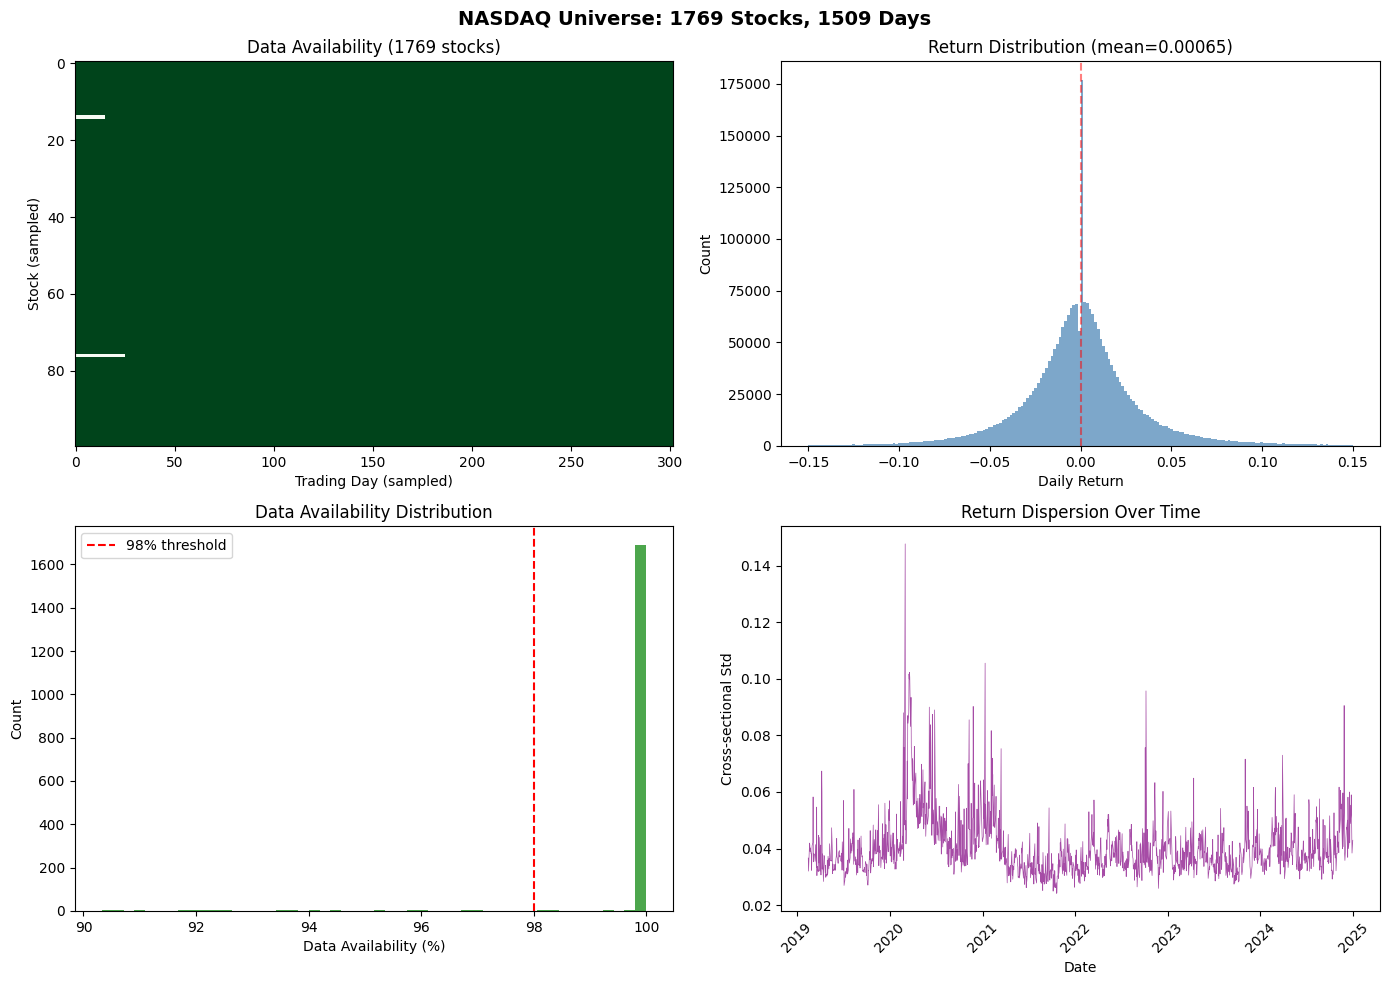

In [ ]:
# ============================================================
# DATA OVERVIEW
# ============================================================
dates = close_filtered.index

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Data availability heatmap (sample)
sample_idx = np.linspace(0, N_stocks-1, min(100, N_stocks), dtype=int)
avail_matrix = all_close[filtered_tickers].notna().values[::5, sample_idx]
axes[0, 0].imshow(avail_matrix.T, aspect='auto', cmap='Greens', interpolation='nearest')
axes[0, 0].set_xlabel('Trading Day (sampled)'); axes[0, 0].set_ylabel('Stock (sampled)')
axes[0, 0].set_title(f'Data Availability ({N_stocks} stocks)')

# 2. Distribution of return ratios
all_returns = all_features[:, 30:, 0].flatten()  # skip first 30 days (MA warmup)
axes[0, 1].hist(all_returns, bins=200, color='steelblue', alpha=0.7,
                range=(-0.15, 0.15))
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Daily Return'); axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title(f'Return Distribution (mean={all_returns.mean():.5f})')

# 3. Number of stocks per data availability tier
avail_pct = all_close[filtered_tickers].notna().sum() / total_days * 100
axes[1, 0].hist(avail_pct, bins=50, color='green', alpha=0.7)
axes[1, 0].axvline(x=98, color='red', linestyle='--', label='98% threshold')
axes[1, 0].set_xlabel('Data Availability (%)'); axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Data Availability Distribution')
axes[1, 0].legend()

# 4. Cross-sectional return dispersion over time
daily_std = np.std(all_features[:, 30:, 0], axis=0)
axes[1, 1].plot(dates[30:], daily_std, color='purple', alpha=0.7, linewidth=0.5)
axes[1, 1].set_xlabel('Date'); axes[1, 1].set_ylabel('Cross-sectional Std')
axes[1, 1].set_title('Return Dispersion Over Time')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle(f'NASDAQ Universe: {N_stocks} Stocks, {N_days} Days', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'data_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Save

In [ ]:
# ============================================================
# SAVE ALL DATA
# ============================================================

# Feature tensor: (N_stocks, N_days, 5)
np.save(os.path.join(DATA_DIR, 'all_features.npy'), all_features)

# Tickers
pd.DataFrame({'ticker': filtered_tickers}).to_csv(
    os.path.join(DATA_DIR, 'tickers.csv'), index=False)

# Dates
pd.DataFrame({'date': dates.strftime('%Y-%m-%d')}).to_csv(
    os.path.join(DATA_DIR, 'dates.csv'), index=False)

# Closing prices (for paper trading later)
close_filtered.to_csv(os.path.join(DATA_DIR, 'closing_prices.csv'))

# Metadata
metadata = {
    'n_stocks': N_stocks,
    'n_days': N_days,
    'n_features': 5,
    'start_date': dates[0].strftime('%Y-%m-%d'),
    'end_date': dates[-1].strftime('%Y-%m-%d'),
    'data_source': 'yfinance',
    'universe': 'NASDAQ',
    'min_availability': 0.98,
    'feature_names': ['return_ratio', 'ma5_norm', 'ma10_norm', 'ma20_norm', 'ma30_norm'],
    'created': datetime.now().strftime('%Y-%m-%d %H:%M'),
}
with open(os.path.join(DATA_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

# Summary
print('Saved files:')
for fname in sorted(os.listdir(DATA_DIR)):
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  {fname:<30} {size_mb:>8.2f} MB')

print(f'\n✅ Step 5a complete!')
print(f'   Universe: {N_stocks} NASDAQ stocks')
print(f'   Period: {dates[0].strftime("%Y-%m-%d")} to {dates[-1].strftime("%Y-%m-%d")}')
print(f'   Features: {all_features.shape}')

Saved files:
  _raw_close_all.csv                62.30 MB
  all_features.npy                 101.83 MB
  closing_prices.csv                44.12 MB
  data_overview.png                  0.20 MB
  dates.csv                          0.02 MB
  metadata.json                      0.00 MB
  tickers.csv                        0.01 MB

✅ Step 5a complete!
   Universe: 1769 NASDAQ stocks
   Period: 2019-01-02 to 2024-12-30
   Features: (1769, 1509, 5)

   Next: Run Step 5b (Graph Construction)
